# Chapter 4 — Electricity Finds Deformation
### *Modern Strain Gage Technology* — Companion Notebook

*Stretch a metal wire and its resistance changes — a whisper of a signal that the bridge circuit turns into a number you can trust.*

**Companion notebook to Chapter 4 — Electricity Finds Deformation.**

The circuit was Samuel Hunter Christie's. He described the balanced four-resistance "diamond" in 1833 while studying the magneto-electric properties of metals, and it went largely unremarked for a decade. Charles Wheatstone proposed it for resistance measurement in 1843, credited Christie openly, and made it famous — and the topology has carried Wheatstone's name ever since. Strain gage measurement appropriates that circuit for a purpose neither man had in mind: one arm is a gage whose resistance changes with deformation, and that change unbalances the bridge into a measurable output voltage.

The linear approximation V_out ≈ V_ex · GF · ε / 4 is what every data-acquisition system implements, and it is adequate for most structural testing. But the exact expression — which accounts for the changing current distribution as the bridge unbalances — is nonlinear, and the error grows with strain. For a constantan gage at GF = 2.0: about 0.1% at 1,000 με, 1% at 10,000 με, nearly 9% at 100,000 με — though that last figure is annealed-constantan territory, well past the ±5% range of a standard foil gage.

Two things about that error are easy to get wrong, and both are shown below. It is **signed**: in tension the instrument underreads, in compression it overreads, and the two are not quite equal in magnitude. And it scales with ΔR/R, not with strain — so a semiconductor gage at GF ≈ 140 reaches the same 1% error at roughly 145 με that a constantan gage does not reach until 10,100 με, a factor of seventy.

**This notebook demonstrates:**
1. Bridge output vs. ΔR/R — exact formula against the linear approximation, with the signed reading error that follows from the difference
2. Bridge nonlinearity vs. strain — quarter-bridge and Poisson half-bridge, and how gage factor moves the correction into or out of the everyday measurement range

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures for this chapter are written here; the book \includegraphics these exact files.
OUT_DIR = Path("../src/media/ch04")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Bridge Output vs. Resistance Change

The bridge is balanced when R₁/R₂ = R₄/R₃ — at balance the output voltage is zero regardless of excitation. Any resistance change in one arm unbalances it and produces an output. For a quarter-bridge (one active gage, three fixed equal resistors), the exact output when one arm changes by ΔR is:

$$V_{out} = V_{ex}\left[\frac{R+\Delta R}{(R+\Delta R)+R} - \frac{R}{R+R}\right] = V_{ex}\,\frac{\Delta R}{4R + 2\Delta R}$$

The linear approximation $V_{out} \approx V_{ex}(\Delta R/R)/4$ holds well when ΔR/R is small — which it is for elastic strain in most metals, where ΔR/R = GF·ε ≈ 0.002 at 1,000 με with a constantan gage.

The right panel shows what the difference between those two expressions costs you. Because the data-acquisition system converts voltage to strain with the *linear* model, the fractional voltage deviation and the fractional strain error are the same number:

$$\frac{\varepsilon_{indicated} - \varepsilon_{true}}{\varepsilon_{true}} = \frac{V_{exact} - V_{linear}}{V_{linear}} = \frac{-\Delta R/R}{2 + \Delta R/R}$$

Read the sign carefully, because it reverses. In **tension** (ΔR/R > 0) the expression is negative: the exact output is smaller than linear, so the instrument **underreads**. In **compression** (ΔR/R < 0) it is positive: the exact output is larger in magnitude, so the instrument **overreads**. The two are not symmetric either — at ΔR/R = ±3% the tensile error is −1.478% and the compressive error is +1.523%, because the denominator moves with the sign. Taking an absolute value anywhere in this calculation destroys exactly the information that makes it useful.

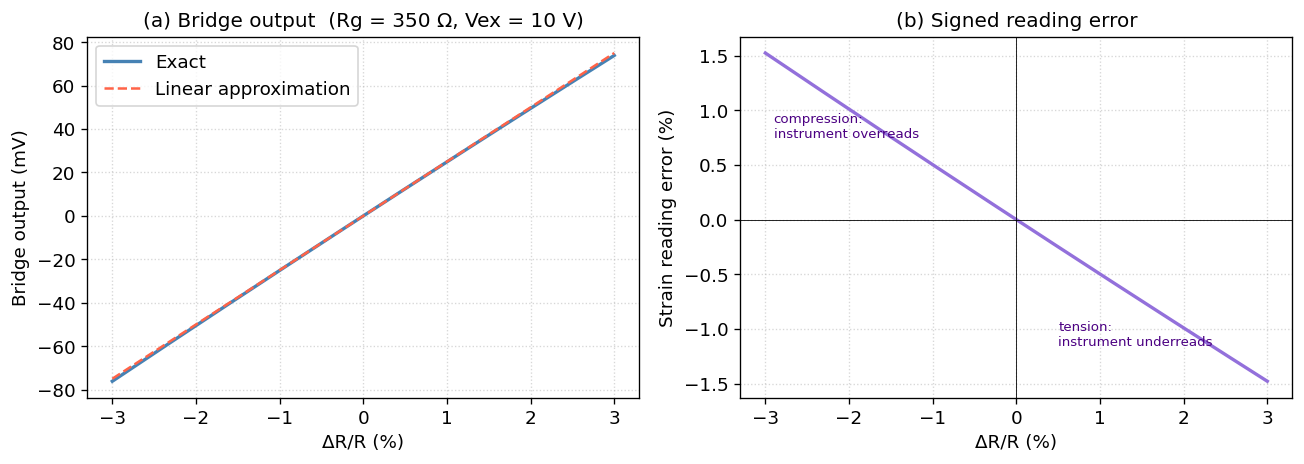

ΔR/R = +3.0%  ->  reading error -1.478%  (underreads)
ΔR/R = -3.0%  ->  reading error +1.523%  (overreads)


In [2]:
# Wheatstone bridge, general four-arm form.
# Arms: R1 (top-left), R2 (bottom-left), R3 (top-right), R4 (bottom-right).
def bridge_output(R1, R2, R3, R4, Vex):
    """Bridge output voltage for arbitrary arm resistances.

    Vout = Vex * (R3/(R3+R4) - R2/(R1+R2)); zero when R1/R2 = R4/R3 (balance).
    Any argument may be a NumPy array (values broadcast).
    """
    return Vex * (R3 / (R3 + R4) - R2 / (R1 + R2))


R_GAGE  = 350.0   # baseline gage resistance (Ω)
V_EX    = 10.0    # excitation voltage (V)
DRR_MAX = 0.03    # sweep fractional resistance change, ±3% (≈15,000 με at GF 2).
                  # Keep this at 0.03: the chapter's Figure 4.5 caption states the
                  # ±3% range, and the panel-(b) annotations are positioned for it.
N_PTS   = 401

# Sweep fractional resistance change ΔR/R in one active arm (arm R3).
dRR = np.linspace(-DRR_MAX, DRR_MAX, N_PTS)          # dimensionless
Vout_exact  = bridge_output(R_GAGE, R_GAGE, R_GAGE * (1 + dRR), R_GAGE, V_EX)
Vout_linear = V_EX * dRR / 4.0                        # Vout ≈ (Vex/4)·(ΔR/R)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(dRR * 100, Vout_exact * 1000, 'steelblue', lw=2, label='Exact')
axes[0].plot(dRR * 100, Vout_linear * 1000, 'tomato', lw=1.5, linestyle='--',
             label='Linear approximation')
axes[0].set_xlabel('ΔR/R (%)')
axes[0].set_ylabel('Bridge output (mV)')
axes[0].set_title(f'(a) Bridge output  (Rg = {R_GAGE:.0f} Ω, Vex = {V_EX:.0f} V)')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.5)

# Signed reading error. NO absolute value: the sign is the physics.
#   Tension     (ΔR/R > 0): negative -> instrument underreads.
#   Compression (ΔR/R < 0): positive -> instrument overreads.
# Equals (Vexact - Vlinear)/Vlinear = -(ΔR/R) / (2 + ΔR/R).
with np.errstate(divide='ignore', invalid='ignore'):
    read_err_pct = 100 * (Vout_exact - Vout_linear) / Vout_linear
read_err_pct[np.isclose(dRR, 0.0)] = 0.0   # removable singularity at balance

axes[1].plot(dRR * 100, read_err_pct, 'mediumpurple', lw=2)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].axvline(0, color='black', lw=0.5)
axes[1].set_xlabel('ΔR/R (%)')
axes[1].set_ylabel('Strain reading error (%)')
axes[1].set_title('(b) Signed reading error')
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].annotate('compression:\ninstrument overreads',
                 xy=(-2.4, read_err_pct[20]), xytext=(-2.9, 0.75),
                 fontsize=8, color='indigo')
axes[1].annotate('tension:\ninstrument underreads',
                 xy=(2.4, read_err_pct[-20]), xytext=(0.5, -1.15),
                 fontsize=8, color='indigo')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig04_nb1_bridge_output_vs_resistance.png',
            bbox_inches='tight', dpi=150)
plt.show()

for probe in (+DRR_MAX, -DRR_MAX):
    err = -probe / (2 + probe) * 100
    verb = 'underreads' if err < 0 else 'overreads'
    print(f"ΔR/R = {probe*100:+.1f}%  ->  reading error {err:+.3f}%  ({verb})")

---
## 2 — Bridge Nonlinearity vs. Strain

The quarter-bridge linear approximation $V_{out}/V_{ex} = \frac{1}{4}GF\varepsilon$ understates the true output in tension. Expressed as a fraction of the true strain, the magnitude of the error is:

$$\eta = \frac{GF\,\varepsilon}{2 + GF\,\varepsilon}$$

where $\varepsilon$ is the true (absolute) strain. In words: the error grows in proportion to $GF\,\varepsilon = \Delta R/R$, so it is negligible for elastic metal strains and only becomes appreciable in the percent-strain regime.

**Rule of thumb, and note the condition attached to it:** since $\eta \approx GF\,\varepsilon/2$, the error in percent approximately equals the strain in percent *only when GF ≈ 2*. At GF = 2.0: 0.1% at 1,000 με, 1% at 10,000 με, ~9% at 100,000 με. The rule fails badly for anything else — an isoelastic gage at GF = 3.2 hits 1% at 6,300 με, and a p-type silicon gage at GF ≈ 140 hits it at about 145 με. Panel (b) below is that comparison.

A Poisson half-bridge (one axial gage, one transverse) is slightly better behaved: the effective sensitivity carries a factor of $(1-\nu)$ in the *denominator* term, giving $\eta = GF(1-\nu)\varepsilon\,/\,[2 + GF(1-\nu)\varepsilon]$.

Bending half-bridges and full-bridge bending or torsion circuits are **exactly linear** — their equal-and-opposite arm arrangement holds the branch currents constant, and the second-order term cancels identically rather than merely being small.

When correction is needed, the indicated strain $\varepsilon_i$ from the linear model converts to true strain by inverting the relation above:

$$\varepsilon = \frac{2\,\varepsilon_i}{2 - GF\,\varepsilon_i}$$

*(Formulation after Micro-Measurements Tech Note TN-507-1, "Errors due to Wheatstone Bridge Nonlinearity.")*

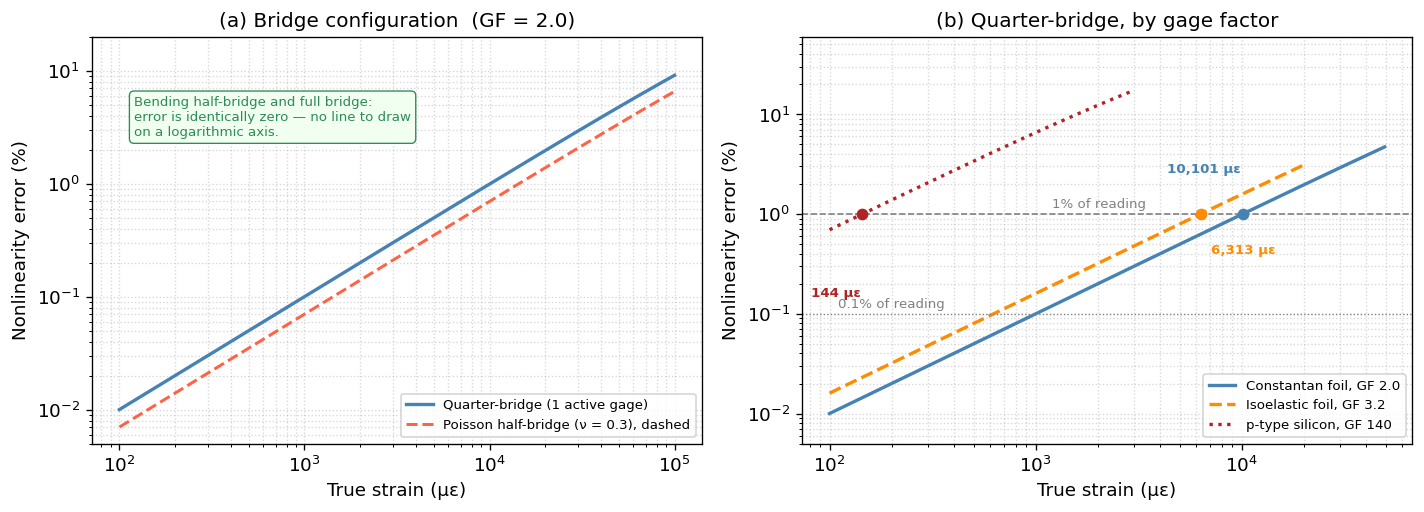

Quarter-bridge correction table (GF = 2.0, tension):

 indicated   eta (%)      true  correction
     500 με     0.050     500 με       0.3 με
    1000 με     0.100    1001 με       1.0 με
    2000 με     0.200    2004 με       4.0 με
    5000 με     0.500    5025 με      25.1 με
   10000 με     1.000   10101 με     101.0 με
   15000 με     1.500   15228 με     228.4 με

Round-trip check, exact bridge -> linear model -> correction:
  via node subtraction, max relative residual: 9.64e-12 (at 14 με)
  via closed form,      max relative residual: 2.69e-16
  The gap between the two is floating-point cancellation, not algebra:
  at low strain the bridge output is a part-per-million difference between
  two nearly equal node potentials, and the subtraction loses ~6 digits.
  That is the numerical shadow of why bridges need a differential amplifier.


In [3]:
# Bridge nonlinearity vs. strain, after Micro-Measurements TN-507-1.
GF    = 2.0     # gage factor (typical constantan foil)
NU    = 0.30    # Poisson's ratio (typical structural metal)
MICRO = 1e-6    # microstrain -> absolute strain


def quarter_bridge_nonlinearity(eps_true, gf=GF):
    """Fractional quarter-bridge nonlinearity η = GF·ε / (2 + GF·ε).

    eps_true is absolute strain (not microstrain). Returns a dimensionless
    fraction (multiply by 100 for percent), the error as a fraction of the
    true strain. One active gage, three fixed arms.
    """
    dRR = gf * eps_true
    return dRR / (2 + dRR)


def poisson_half_bridge_nonlinearity(eps_true, gf=GF, nu=NU):
    """Fractional nonlinearity for a Poisson half-bridge.

    One active axial gage plus one transverse (Poisson) gage in the adjacent
    arm of the same branch. Exact output/Vex = GF·ε(1+ν) / [2(2 + GF·ε(1-ν))],
    so the (1-ν) factor appears in the nonlinear term only.
    """
    dRR = gf * (1 - nu) * eps_true
    return dRR / (2 + dRR)


def true_strain(eps_indicated, gf=GF):
    """Correct a linear-model indicated strain back to true strain.

    ε = 2·ε_i / (2 - GF·ε_i); the exact inverse of the quarter-bridge
    nonlinearity. eps_indicated is absolute strain.
    """
    return 2 * eps_indicated / (2 - gf * eps_indicated)


# Gage types for panel (b): (label, gage factor, usable strain limit in με)
# Each curve is drawn only over its gage's usable strain range, so the limits
# must match the alloy data cited in the sources table below: EA constantan
# ±5%, ED isoelastic ±2%. (Annealed constantan, EP series, reaches ±20% — but
# that is a different gage from the one labelled here.)
GAGE_TYPES = [
    ('Constantan foil, GF 2.0',      2.0,    50000.0),
    ('Isoelastic foil, GF 3.2',      3.2,    20000.0),
    ('p-type silicon, GF 140',     140.0,     3000.0),
]

eps_ue = np.logspace(2, 5, 500)                            # 100 to 100 000 με
eta_q  = quarter_bridge_nonlinearity(eps_ue * MICRO)
eta_ph = poisson_half_bridge_nonlinearity(eps_ue * MICRO)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# --- (a) bridge configuration, at a fixed gage factor ------------------------
axes[0].loglog(eps_ue, eta_q * 100, 'steelblue', lw=2,
               label='Quarter-bridge (1 active gage)')
axes[0].loglog(eps_ue, eta_ph * 100, 'tomato', lw=1.8, linestyle='--',
               label=f'Poisson half-bridge (ν = {NU}), dashed')
axes[0].set_ylim(0.005, 20)
axes[0].text(120, 6.0,
             'Bending half-bridge and full bridge:\nerror is identically zero '
             '— no line to draw\non a logarithmic axis.',
             fontsize=8, color='seagreen', va='top',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='honeydew',
                       edgecolor='seagreen', linewidth=0.8))
axes[0].set_xlabel('True strain (με)')
axes[0].set_ylabel('Nonlinearity error (%)')
axes[0].set_title(f'(a) Bridge configuration  (GF = {GF})')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(True, which='both', linestyle=':', alpha=0.5)

# --- (b) gage factor is what actually moves the correction ------------------
# Placement for the 1%-crossing labels, kept clear of the curves by hand:
# (x multiplier on the crossing strain, y in percent, horizontal alignment).
# The isoelastic label sits below-RIGHT of its marker -- placed below-left it is
# struck through by its own curve, which descends through exactly that region.
LABEL_POS = {'Constantan foil, GF 2.0': (0.98, 2.60, 'right'),
             'Isoelastic foil, GF 3.2': (1.12, 0.40, 'left'),
             'p-type silicon, GF 140':  (0.98, 0.15, 'right')}

# Line style as well as color, so the three gages stay distinct in gray print.
for (label, gf, limit_ue), color, style in zip(GAGE_TYPES,
                                               ['steelblue', 'darkorange', 'firebrick'],
                                               ['-', '--', ':']):
    mask = eps_ue <= limit_ue
    axes[1].loglog(eps_ue[mask],
                   quarter_bridge_nonlinearity(eps_ue[mask] * MICRO, gf) * 100,
                   lw=2, color=color, linestyle=style, label=label)
    # Strain at which this gage reaches 1% nonlinearity: η=0.01 -> ΔR/R=2·η/(1-η)
    eps_1pct = (2 * 0.01 / (1 - 0.01)) / gf / MICRO
    if eps_1pct <= limit_ue:
        axes[1].plot(eps_1pct, 1.0, 'o', color=color, ms=6, zorder=5)
        x_mult, y_lbl, align = LABEL_POS[label]
        axes[1].annotate(f'{eps_1pct:,.0f} με', xy=(eps_1pct, 1.0),
                         xytext=(eps_1pct * x_mult, y_lbl), fontsize=8,
                         color=color, ha=align, fontweight='bold')

axes[1].axhline(1.0, color='gray', lw=1.0, linestyle='--')
axes[1].axhline(0.1, color='gray', lw=0.8, linestyle=':')
axes[1].text(1200, 1.15, '1% of reading', fontsize=8, color='gray')
axes[1].text(110, 0.115, '0.1% of reading', fontsize=8, color='gray')
axes[1].set_ylim(0.005, 60)
axes[1].set_xlabel('True strain (με)')
axes[1].set_ylabel('Nonlinearity error (%)')
axes[1].set_title('(b) Quarter-bridge, by gage factor')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig04_nb2_bridge_nonlinearity.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Correction table, quarter-bridge in tension -----------------------------
ei_vals = [500, 1000, 2000, 5000, 10000, 15000]        # indicated strain (με)
print(f"Quarter-bridge correction table (GF = {GF}, tension):\n")
print(f"{'indicated':>10}{'eta (%)':>10}{'true':>10}{'correction':>12}")
for ei in ei_vals:
    et = true_strain(ei * MICRO) / MICRO
    eta_i = quarter_bridge_nonlinearity(et * MICRO) * 100
    print(f"{ei:>8} με{eta_i:>10.3f}{et:>8.0f} με{et - ei:>10.1f} με")

# --- Self-check: the correction must round-trip through the exact circuit ----
# Drive the exact circuit, read it back through the linear model the way a data
# acquisition system does, then correct. The recovered strain must equal the input.
eps_check = np.logspace(1, 5, 200) * MICRO                  # 10 to 100 000 με

# Route 1: the literal four-arm subtraction, as the circuit computes it.
V_nodes = bridge_output(R_GAGE, R_GAGE, R_GAGE * (1 + GF * eps_check), R_GAGE, V_EX)
# Route 2: the algebraically identical closed form, Vex\u00b7\u0394R/R / (4 + 2\u0394R/R).
dRR_check = GF * eps_check
V_closed = V_EX * dRR_check / (4 + 2 * dRR_check)


def round_trip(V):
    """Exact bridge voltage -> DAQ's linear strain -> corrected true strain."""
    eps_indicated = 4 * V / (V_EX * GF)
    return true_strain(eps_indicated)


res_nodes = np.abs(round_trip(V_nodes) - eps_check) / eps_check
res_closed = np.abs(round_trip(V_closed) - eps_check) / eps_check

print("\nRound-trip check, exact bridge -> linear model -> correction:")
print(f"  via node subtraction, max relative residual: {res_nodes.max():.2e} "
      f"(at {eps_check[res_nodes.argmax()] / MICRO:.0f} με)")
print(f"  via closed form,      max relative residual: {res_closed.max():.2e}")
print("  The gap between the two is floating-point cancellation, not algebra:")
print("  at low strain the bridge output is a part-per-million difference between")
print("  two nearly equal node potentials, and the subtraction loses ~6 digits.")
print("  That is the numerical shadow of why bridges need a differential amplifier.")

assert res_closed.max() < 1e-14, "correction does not invert the exact bridge response"
assert res_nodes.max() < 1e-10, "node-form round trip worse than cancellation explains"

### Figures 4.5 and 4.6 — sources and verification

| Item | Source |
|---|---|
| The bridge circuit | Christie, S. H. (1833). "Experimental Determination of the Laws of Magneto-Electric Induction in Different Masses of the Same Metal, and Its Intensity in Different Metals." *Philosophical Transactions of the Royal Society of London* 123, 95–142. |
| Its popularization | Wheatstone, C. (1843). "An Account of Several New Instruments and Processes for Determining the Constants of a Voltaic Circuit." *Philosophical Transactions of the Royal Society of London* 133, 303–327. |
| Nonlinearity formulation and correction | Micro-Measurements Tech Note **TN-507-1**, *Errors due to Wheatstone Bridge Nonlinearity*. Document number and title verified against the Micro-Measurements technical-note index. |
| Foil alloy gage factors and strain ranges | Micro-Measurements gage series data: constantan (EA series, ±5% strain range), isoelastic (ED series, ±2%), annealed constantan (EP series, ±20%). |

**Nothing here is taken on authority.** Every relation plotted above is derived from the four-arm bridge expression in `bridge_output`, and the final cell proves it: it drives the *exact* circuit at strains from 10 to 100,000 με, reads the result back through the *linear* model the way a data-acquisition system would, applies `true_strain`, and asserts the recovered value matches the input to within floating-point precision. If any of the algebra were wrong, that assertion would fail.

That check also surfaces something worth seeing. It runs the round trip twice — once through the literal four-arm node subtraction the circuit performs, once through the algebraically identical closed form — and the two do not agree equally well. The closed form recovers the input to about 3×10⁻¹⁶; the node subtraction only to about 1×10⁻¹¹, and its worst case is at the *low*-strain end. Nothing is wrong with the algebra. At 10 με the bridge output is a five-microvolt difference between two five-volt node potentials — a part in a million — and subtracting two nearly equal doubles throws away six significant digits. It is the arithmetic rehearsing the physical problem: the same vanishing difference is why a bridge is useless without a high-gain differential amplifier, and why the next chapters spend so long on getting one right.

**Notes.**

1. **The reading error is signed, and the sign is the useful part.** Tension underreads, compression overreads. The asymmetry between them (−1.478% vs. +1.523% at ΔR/R = ±3%) comes from the ΔR/R term in the denominator, and it is real — not a rounding artifact.
2. **The exactly-linear configurations are exactly linear.** For a bending half-bridge with arms R(1+a) and R(1−a), the output is V_ex·a/2 with no second-order term at all — the a² terms cancel identically. This is a structural property of the circuit, not a small-signal approximation, which is why bending and torsion transducers are built this way.
3. **Semiconductor gages carry a second nonlinearity this figure does not show.** Panel (b) plots only the *bridge* nonlinearity, which scales with ΔR/R and is therefore severe at GF ≈ 140. Silicon gages are also nonlinear in their own ΔR/R-versus-strain response, and that error is separate and additive. The 145 με crossing shown is a lower bound on where correction becomes necessary, not the whole story.
4. **Gage factor and Poisson's ratio are nominal.** GF = 2.0 and ν = 0.30 are round first-encounter values. A real constantan gage is supplied with a measured gage factor near 2.05–2.10 on its package, and using the nominal value instead is itself a larger error than the bridge nonlinearity below about 2,000 με.

---
## Where to take this next

- **Add lead-wire resistance.** Extend `bridge_output` to include the resistance of the gage's lead wires in series with the active arm, then plot how a long two-wire hookup desensitizes the bridge — and show how the three-wire quarter-bridge cancels most of that error.
- **Separate the two semiconductor nonlinearities.** Panel (b) shows only the bridge's contribution at GF ≈ 140. Add the gage's own ΔR/R-versus-strain curvature from a silicon gage datasheet and plot the two error terms alongside each other; which one dominates, and at what strain, decides how a piezoresistive transducer is calibrated.
- **Put the correction in an error budget.** Note 4 above claims that using a nominal GF = 2.0 instead of the supplied 2.05–2.10 costs more than the bridge nonlinearity below roughly 2,000 με. Verify it: plot both error terms on the same axes and find the crossover. That comparison is the honest way to decide whether the nonlinearity correction belongs in your procedure at all.